In [9]:
import numpy as np
import pandas as pd
import uproot
from pathlib import Path

import matplotlib.pyplot as plt
from mutools.plotting import use_style
from mutools.plotting.helpers import mark_axis

use_style('rootlike')

PATH = Path('/Users/mueller/data/spineosc')

# File to open for the 'sim' (MC) sample per detector/run.
DETECTOR_FILES = {
    'sbnd':        'v1.0.10/spineosc_numu_sbnd_v1.0.10_nosyst.root',
    'icarus_run2': 'v1.0.10/spineosc_numu_icarus_run2_v1.0.10_nosyst.root',
    'icarus_run4': 'v1.0.10/spineosc_numu_icarus_run4_v1.0.10_nosyst.root',
}
DETECTOR_KEYS = {
    'sbnd': 'sbnd',
    'icarus_run2': 'icarus_run2',
    'icarus_run4': 'icarus_run4',
}

# Trigger-emulation PE-to-threshold calibration, its +/-1 sigma
# uncertainty, and the PE-equivalent threshold itself -- detector/run
# specific, supplied directly (not derivable from the ntuples).
TRIGGER_CONFIG = {
    'sbnd': {'scale': 0.647, 'sigma': 0.004, 'threshold': 2000},
    'icarus_run2': {'scale': 0.615, 'sigma': 0.018, 'threshold': 6000},
    'icarus_run4': {'scale': 0.361, 'sigma': 0.013, 'threshold': 3000},
}

DETECTOR_LABELS = {
    'sbnd': r'$\bf{SBND}$',
    'icarus_run2': r'$\bf{ICARUS}$ Run 2',
    'icarus_run4': r'$\bf{ICARUS}$ Run 4',
}
DETECTOR_TITLES = {
    'sbnd': 'SBND Simulation',
    'icarus_run2': 'ICARUS Run 2 Simulation',
    'icarus_run4': 'ICARUS Run 4 Simulation',
}

SAVEPATH = Path('/Users/mueller/Projects/spineosc_technote/figures')
SAVEPATH.mkdir(parents=True, exist_ok=True)

In [2]:
signal = {}

for detector, filename in DETECTOR_FILES.items():
    rf = uproot.open(PATH / filename)
    key = DETECTOR_KEYS[detector]
    signal[detector] = rf[f'events/{key}/signal'].arrays(library='pd')
    print(f"{detector}: signal events = {len(signal[detector])}")

sbnd: signal events = 573160
icarus_run2: signal events = 141395
icarus_run4: signal events = 234033


In [4]:
# Signal definition -- true_category 0 (CCQE-like, 1p) or 2 (n-proton),
# matching handcrafted.ipynb. The `signal` tree is already restricted to
# these two categories, so this mask is a no-op there, but kept explicit
# in case it's ever applied to a broader table.
apply_signal_tpc = lambda df: (df['true_fiducialize_cathode'] == 1)
apply_signal_ccqe = lambda df: (df['true_category'] == 0) & apply_signal_tpc(df)
apply_signal_nproton = lambda df: (df['true_category'] == 2) & apply_signal_tpc(df)
apply_signal = lambda df: apply_signal_ccqe(df) | apply_signal_nproton(df)

# TPC Preselection -- this project's established base-selection cut
# (matches select_full_dent in detvar.ipynb/trigger.ipynb), replacing
# handcrafted.ipynb's reco_fiducial_cut + reco_containment_cut (neither
# exists in this schema).
apply_tpc_cut = lambda df: (df['reco_fiducialize_cathode'] == 1) & (df['reco_fiducial_cut_osc']) & (df['reco_user_containment_cut'] == 1)

apply_shower_multiplicity = lambda df: (df['reco_photon_multiplicity'] == 0) & (df['reco_electron_multiplicity'] == 0)
apply_pion_multiplicity = lambda df: (df['reco_pion_multiplicity'] == 0)
apply_proton_multiplicity_1p = lambda df: (df['reco_proton_multiplicity'] == 1)
apply_proton_multiplicity_multip = lambda df: (df['reco_proton_multiplicity'] > 1)
apply_proton_multiplicity = lambda df: apply_proton_multiplicity_1p(df) | apply_proton_multiplicity_multip(df)
apply_muon_cut = lambda df: (df['reco_muon_multiplicity'] == 1)

In [11]:
def make_ratio(
    energy: pd.Series,
    mask0: pd.Series,
    mask1: pd.Series,
    edges: np.ndarray
) -> np.ndarray:
    """
    Bin the energy variable according to the provided edges for the two
    provided masks and return the bin-by-bin ratio of the two
    histograms.

    Parameters
    ----------
    energy : pd.Series
        The variable to be binned.
    mask0 : pd.Series
        The first mask to be applied to the energy variable before
        binning.
    mask1 : pd.Series
        The second mask to be applied to the energy variable before
        binning.
    edges : np.ndarray
        The edges to be used for binning the energy variable.

    Returns
    -------
    np.ndarray
        The bin-by-bin ratio of the two histograms.
    """
    hist0, _ = np.histogram(energy[mask0], bins=edges)
    hist1, _ = np.histogram(energy[mask1], bins=edges)
    ratio = hist1 / hist0
    return ratio


def add_line(
    ax: plt.Axes,
    energy_masked: pd.Series,
    ratio: np.ndarray,
    edges: np.ndarray,
    label: str = None,
    color: str = None
) -> None:
    integrated_efficiency = np.sum(ratio * np.histogram(energy_masked, bins=edges)[0]) / np.sum(np.histogram(energy_masked, bins=edges)[0])

    ax.step(
        edges,
        np.concatenate([ratio, [ratio[-1]]]),
        where='post',
        label=f'{label} ({integrated_efficiency:.1%})',
        color=color
    )


def build_efficiency_plot(
    df: pd.DataFrame,
    apply_signal: callable,
    apply_pcut: callable,
    edges: np.ndarray,
    var_key: str = 'true_neutrino_energy',
    xlabel: str = 'True Neutrino Energy [GeV]',
    detector_label: str = None,
    channel_label: str = None,
    mark_fs: str = None,
    savefig: str = None
) -> None:
    figure, ax = plt.subplots(figsize=(8, 6))
    energy = df[var_key]

    # Initialize selection to all True, then apply cuts sequentially
    selection = np.repeat(True, len(df))

    # Signal mask
    mask_signal = apply_signal(df)

    # Cuts
    cuts = {
        'TPC Preselection': apply_tpc_cut,
        'Shower Veto': apply_shower_multiplicity,
        'Pion Veto': apply_pion_multiplicity,
        'Proton Requirements': apply_pcut,
        'Muon Requirements': apply_muon_cut
    }

    # Apply cuts sequentially and plot efficiency after each cut
    for cut_name, cut_func in cuts.items():
        selection &= cut_func(df)
        ratio = make_ratio(energy, mask_signal, mask_signal & selection, edges)
        add_line(ax, energy[mask_signal], ratio, edges, label=f'{cut_name}')

    # Finalize plot
    ax.set_xlim(edges[0], edges[-1])
    ax.set_ylim(0, 1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Efficiency')
    mark_axis(ax, r'$\bf{SBN}$ Analysis-in-Progress')
    if mark_fs:
        mark_axis(ax, mark_fs, alignment='right')

    # Set legend title
    legend = ax.legend()
    title = detector_label if channel_label is None else f"{detector_label}\n{channel_label}"
    legend.set_title(title)
    legend.get_title().set_fontweight("bold")
    legend.get_title().set_fontsize(14)
    legend.get_title().set_color("#d67a11")

    # Save figure if requested
    if savefig is not None:
        figure.savefig(savefig)

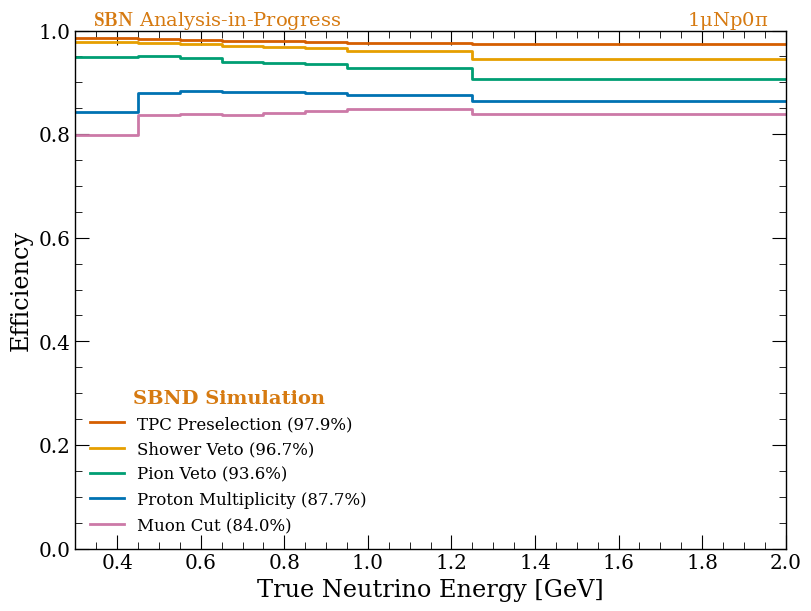

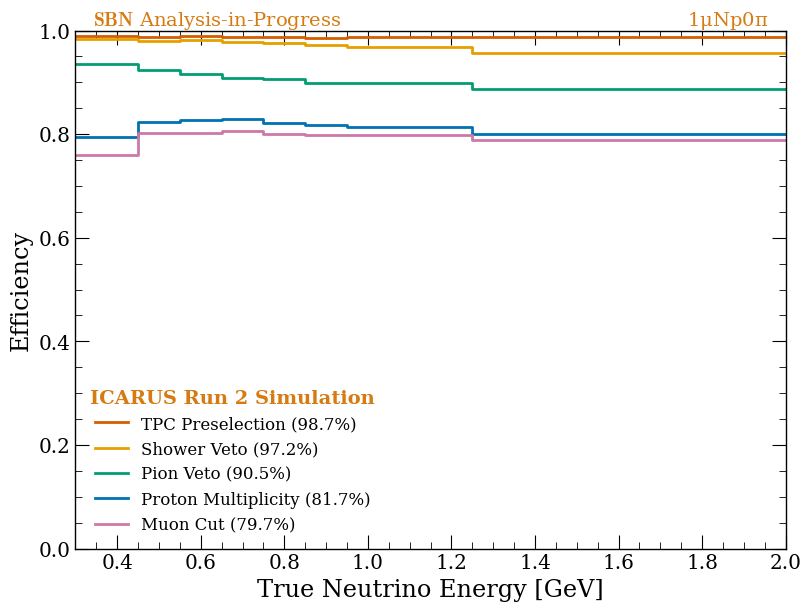

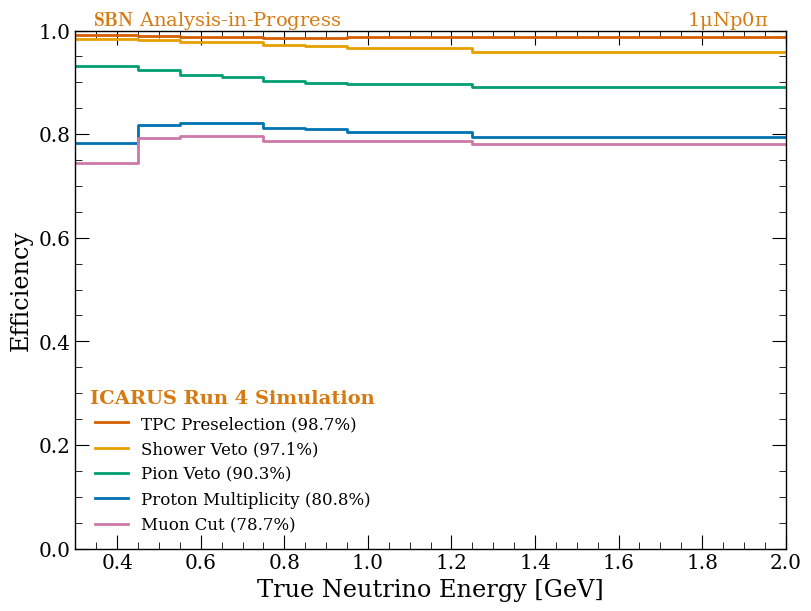

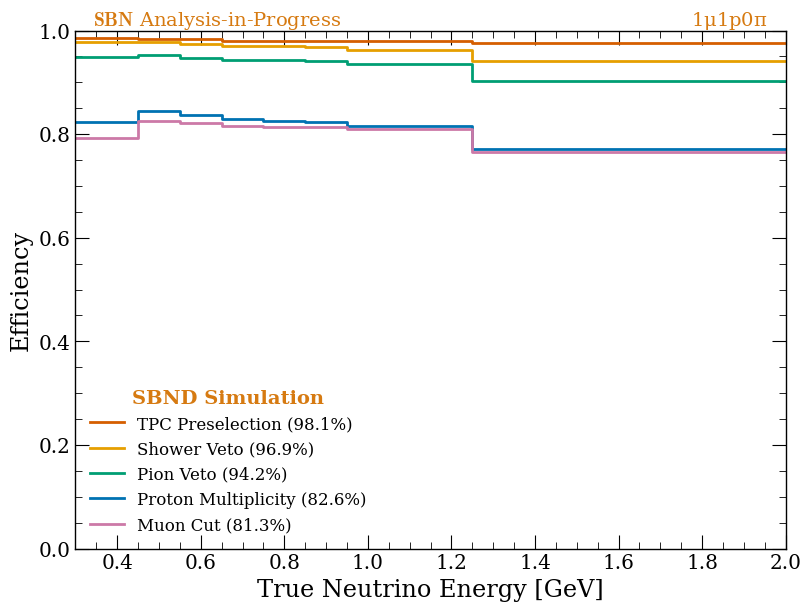

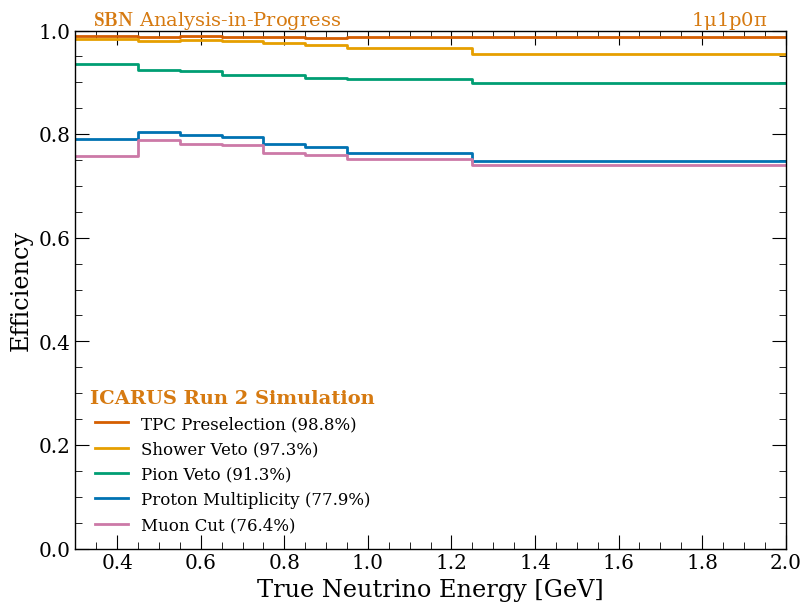

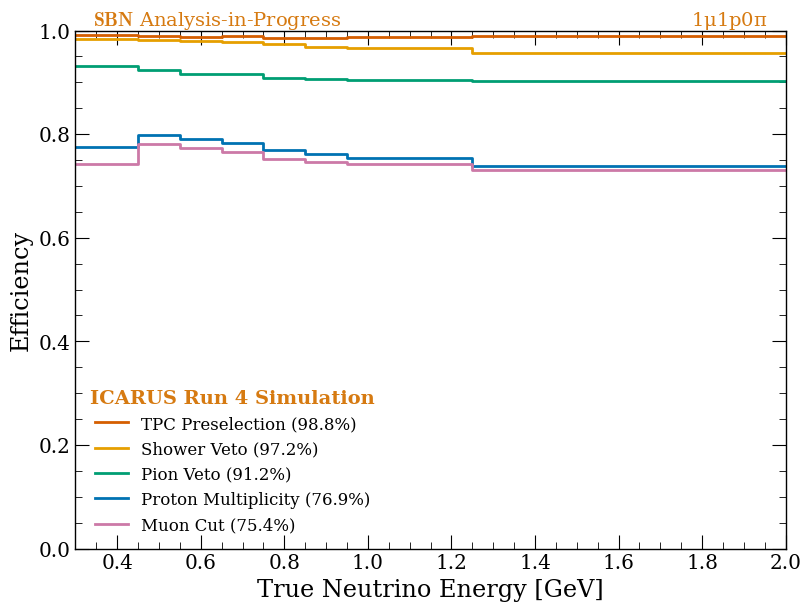

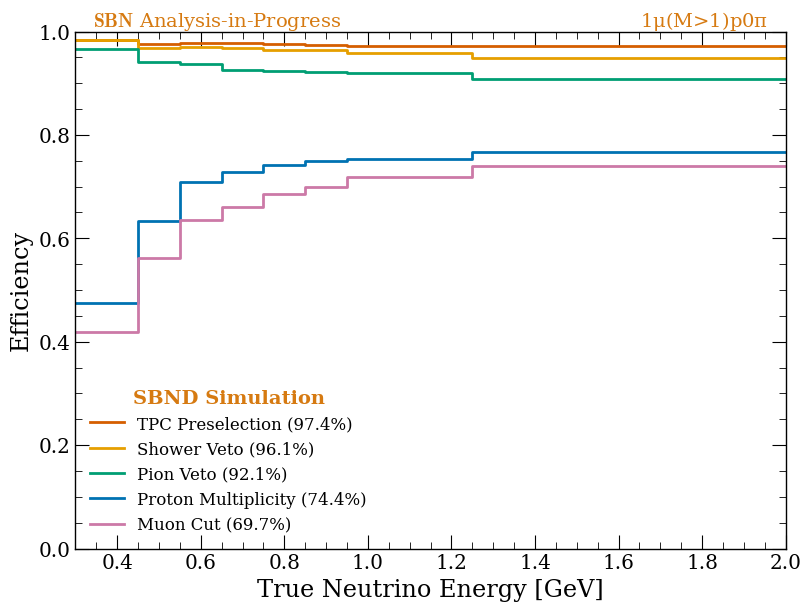

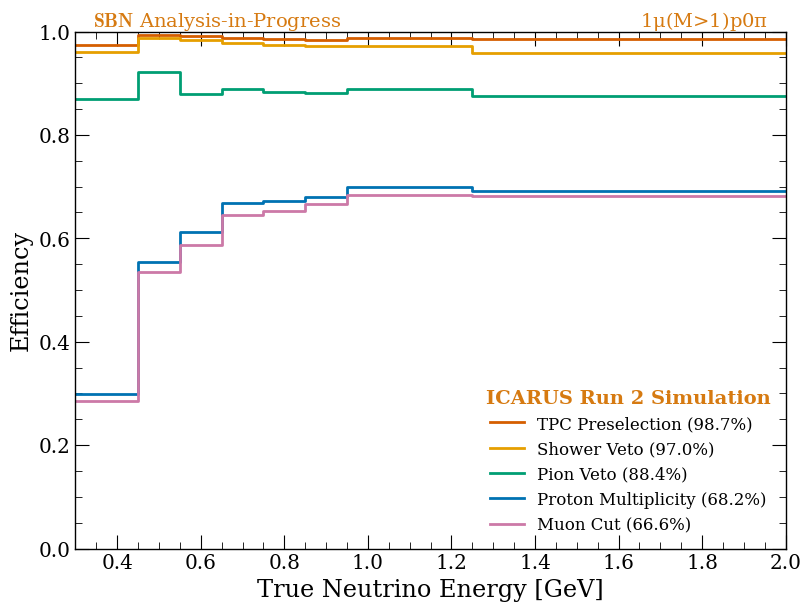

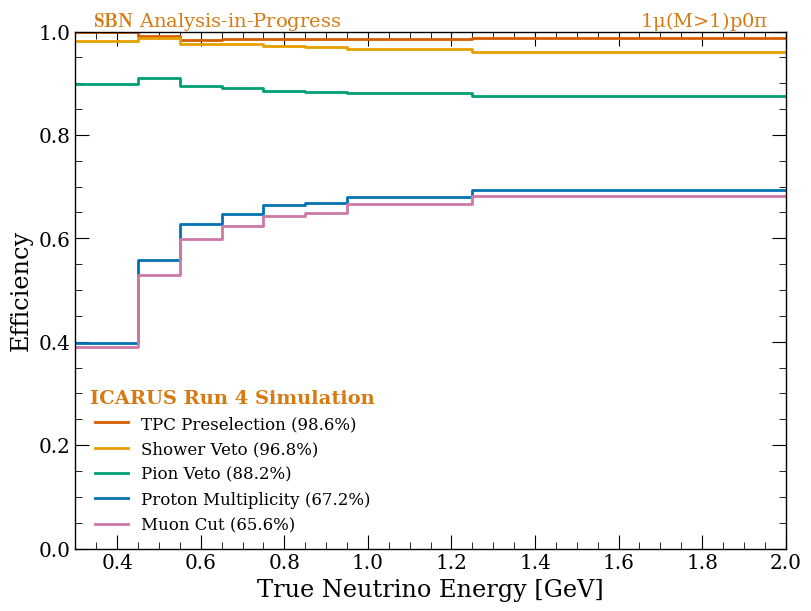

In [10]:
# Matches this project's established reco/true energy edges (trigger.ipynb),
# which are also identical to the external vars.toml's `true_energy` variable.
# handcrafted.ipynb further halves the resolution for the efficiency plot
# specifically (edges[::2]), presumably for per-bin statistics.
edges = np.array([0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.25, 1.5, 2.0])
edges_efficiency = edges[::2]

# Only the currently-active configuration in handcrafted.ipynb: a single
# inclusive channel (any proton multiplicity >= 1), not the disabled
# single-proton/multi-proton split. Detector identity goes into the legend
# title (via detector_label), matching handcrafted.ipynb -- not a second
# mark_axis call, which would collide with the "Analysis-in-Progress"
# watermark build_efficiency_plot already places top-left.
for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal,
        apply_proton_multiplicity,
        edges_efficiency,
        var_key='true_neutrino_energy',
        xlabel='True Neutrino Energy [GeV]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$Np0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_true_neutrino_energy.pdf'
    )

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal_ccqe,
        apply_proton_multiplicity_1p,
        edges_efficiency,
        var_key='true_neutrino_energy',
        xlabel='True Neutrino Energy [GeV]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$1p0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_true_neutrino_energy_singlep.pdf'
    )

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal_nproton,
        apply_proton_multiplicity_multip,
        edges_efficiency,
        var_key='true_neutrino_energy',
        xlabel='True Neutrino Energy [GeV]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$(M>1)p0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_true_neutrino_energy_multip.pdf'
    )

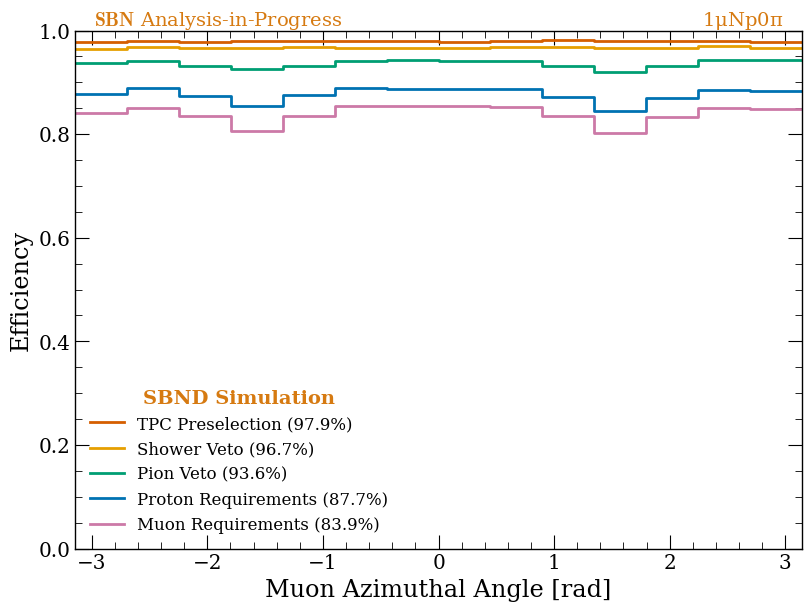

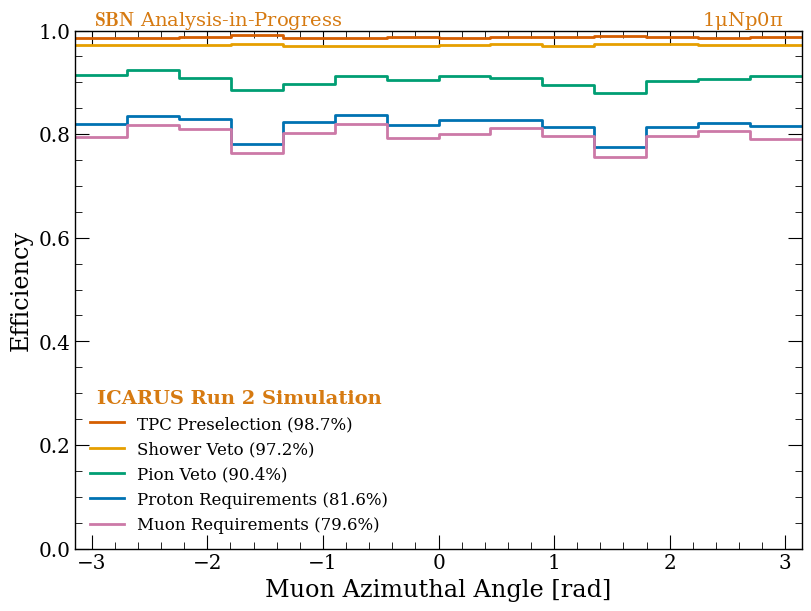

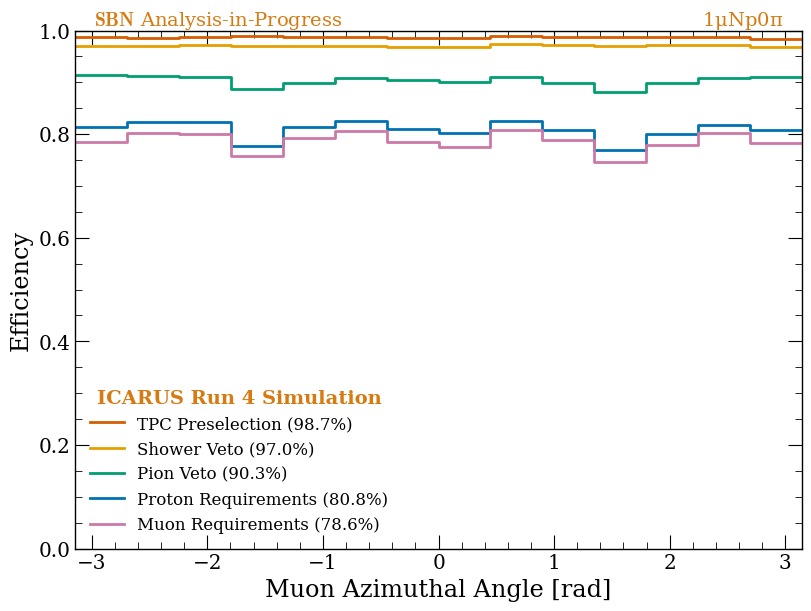

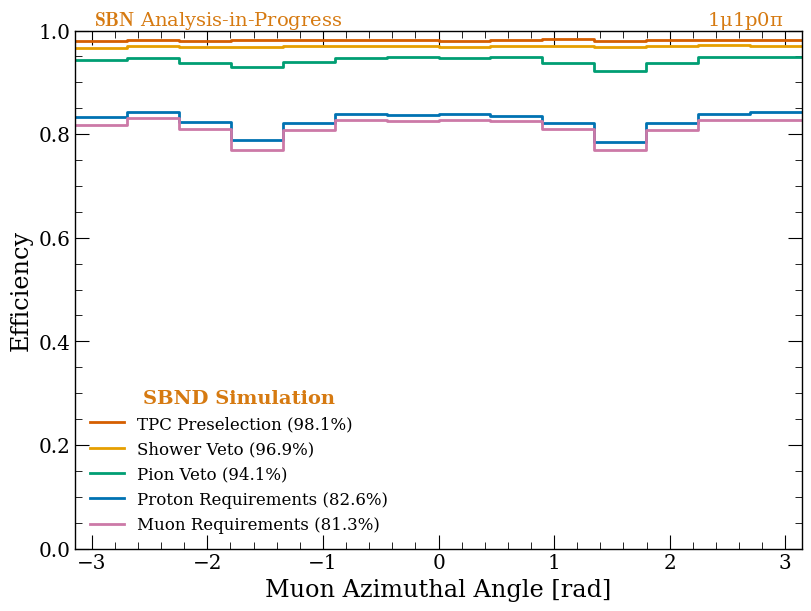

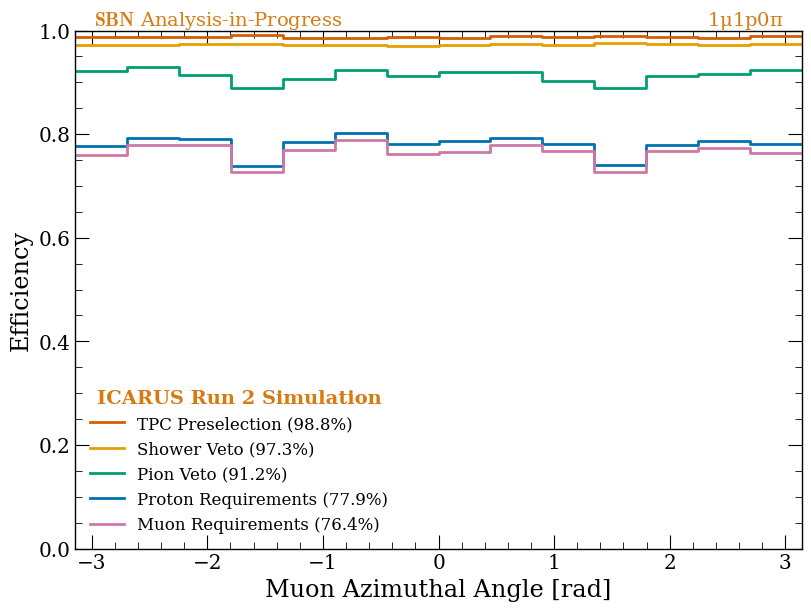

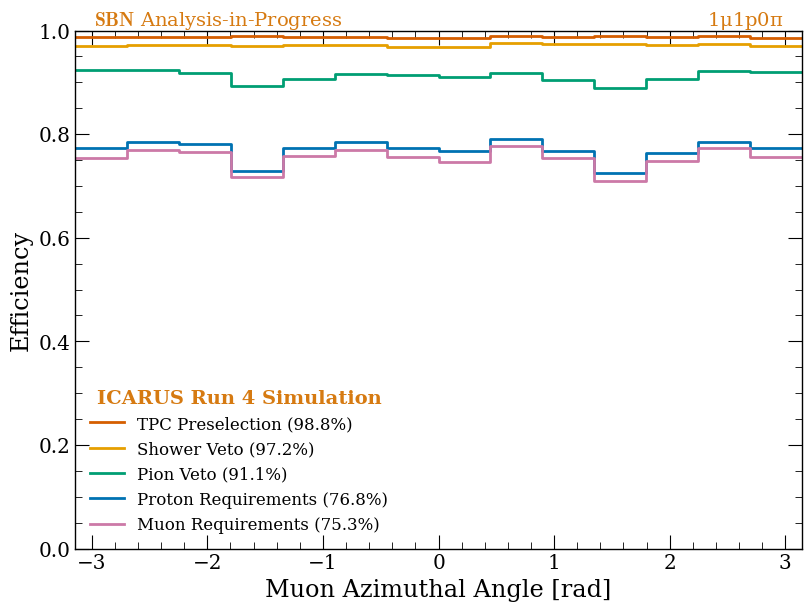

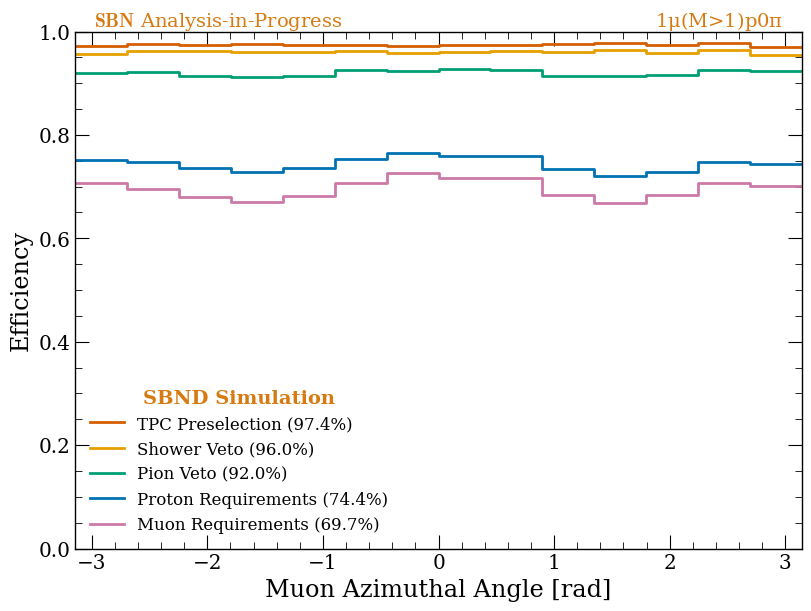

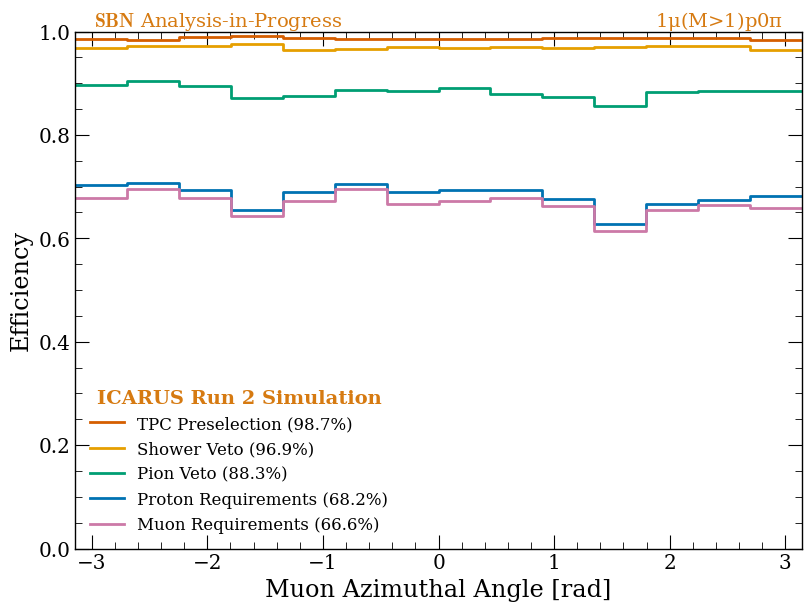

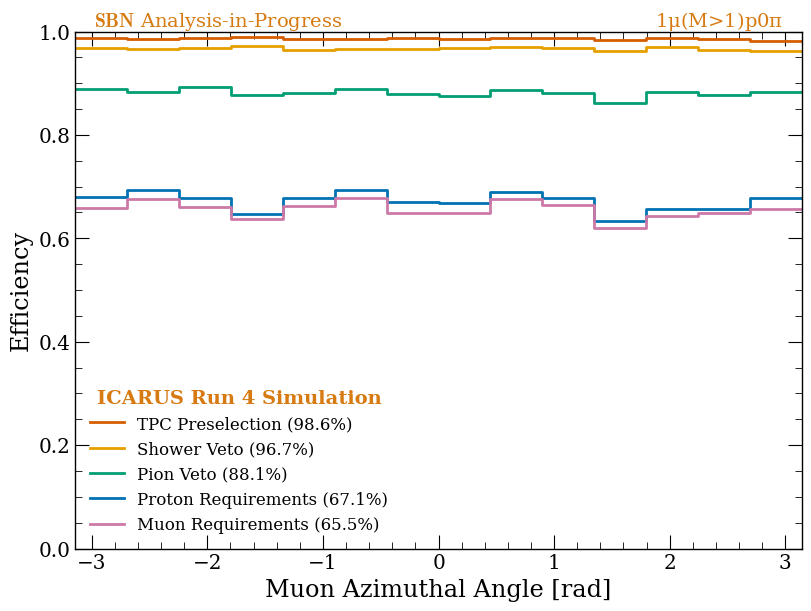

In [16]:
edges_efficiency = np.linspace(-np.pi, np.pi, 15)

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal,
        apply_proton_multiplicity,
        edges_efficiency,
        var_key='true_leading_muon_azimuthal_angle',
        xlabel='Muon Azimuthal Angle [rad]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$Np0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_muon_azimuthal_angle.pdf'
    )

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal_ccqe,
        apply_proton_multiplicity_1p,
        edges_efficiency,
        var_key='true_leading_muon_azimuthal_angle',
        xlabel='Muon Azimuthal Angle [rad]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$1p0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_muon_azimuthal_angle_singlep.pdf'
    )

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal_nproton,
        apply_proton_multiplicity_multip,
        edges_efficiency,
        var_key='true_leading_muon_azimuthal_angle',
        xlabel='Muon Azimuthal Angle [rad]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$(M>1)p0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_muon_azimuthal_angle_multip.pdf'
    )

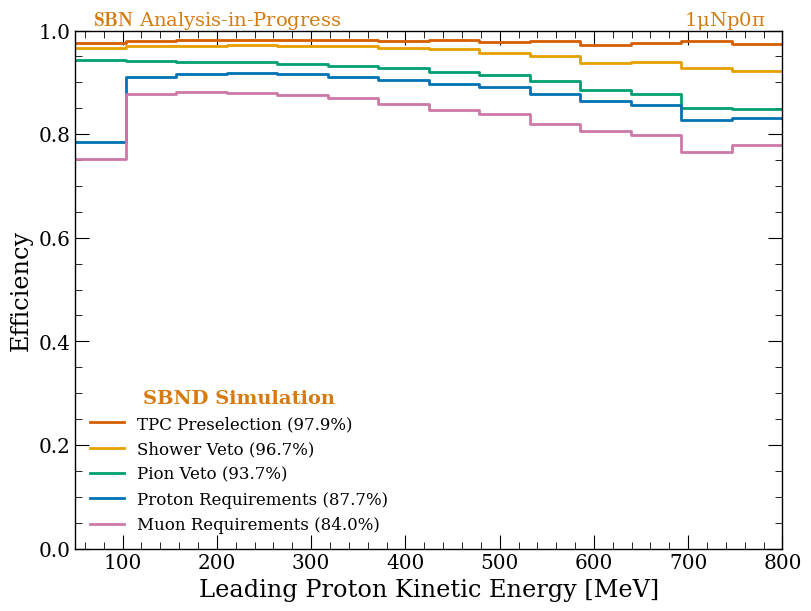

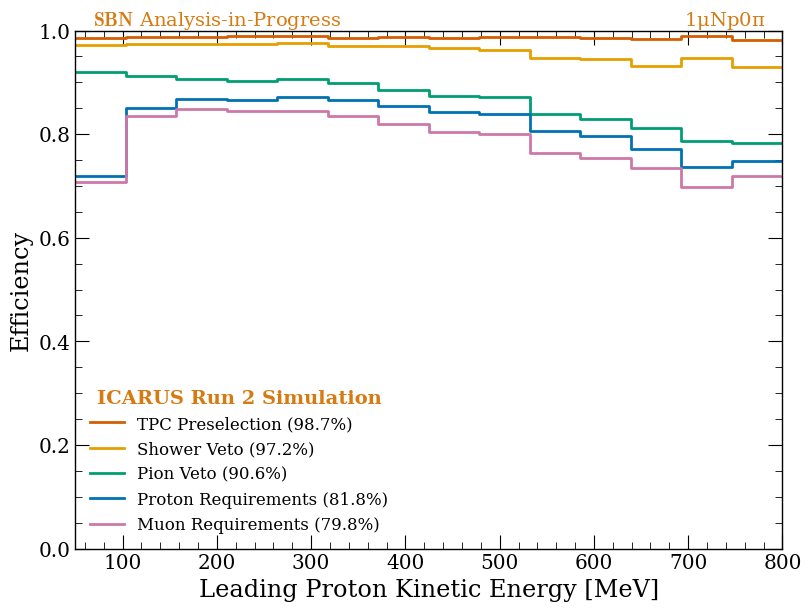

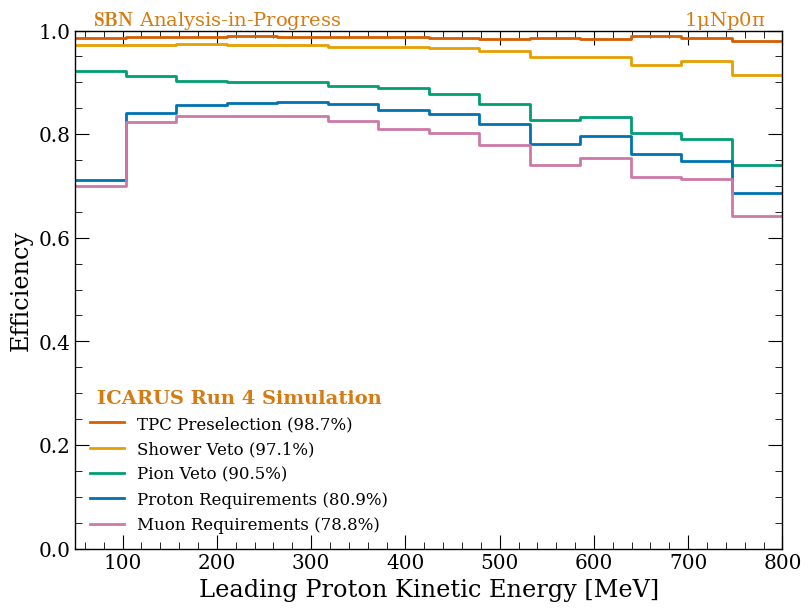

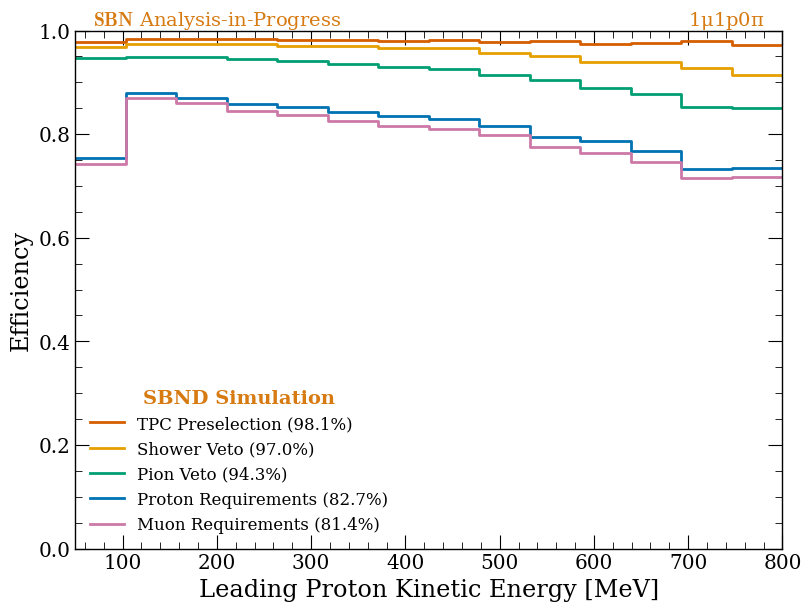

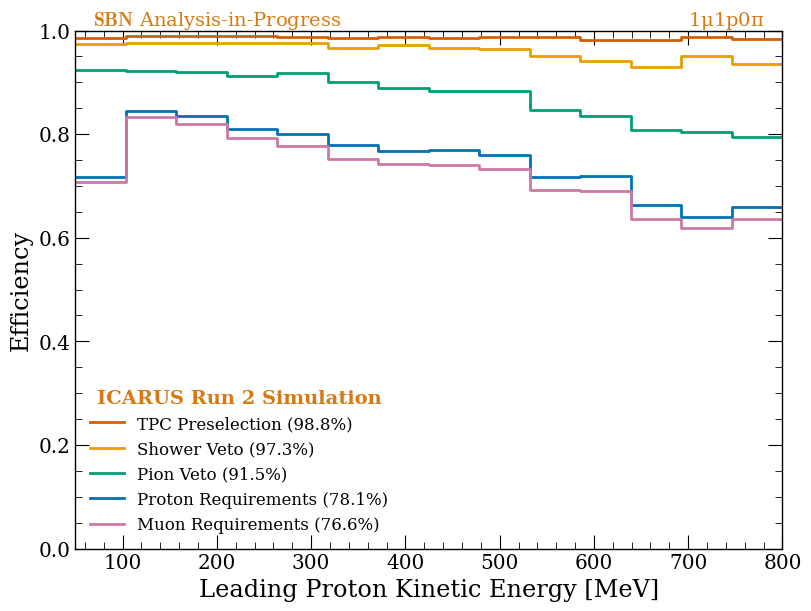

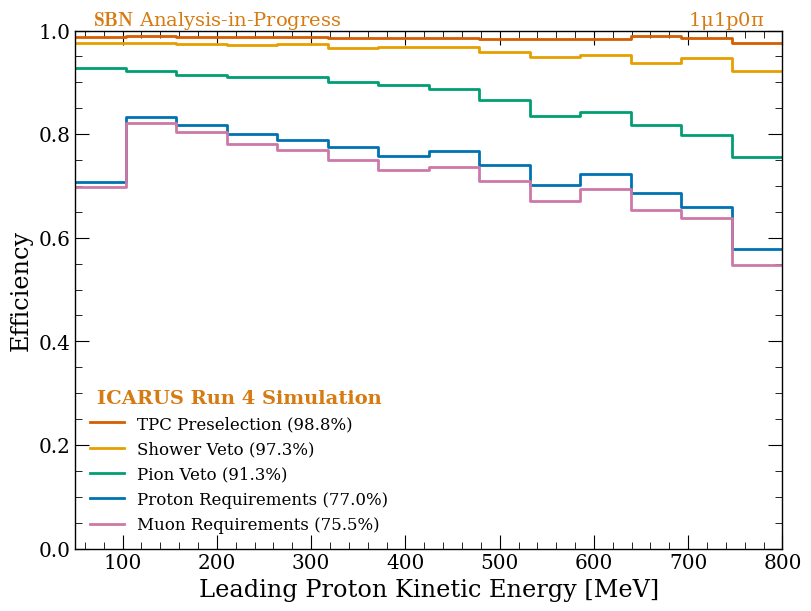

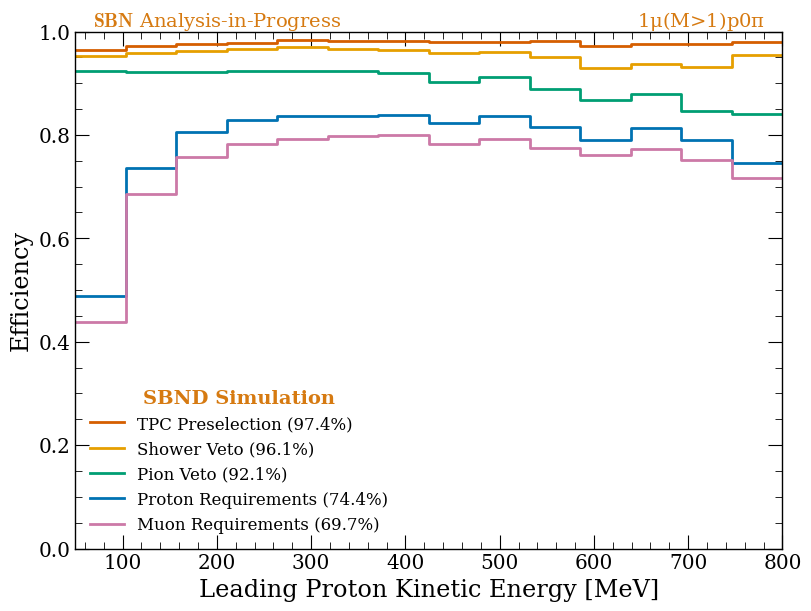

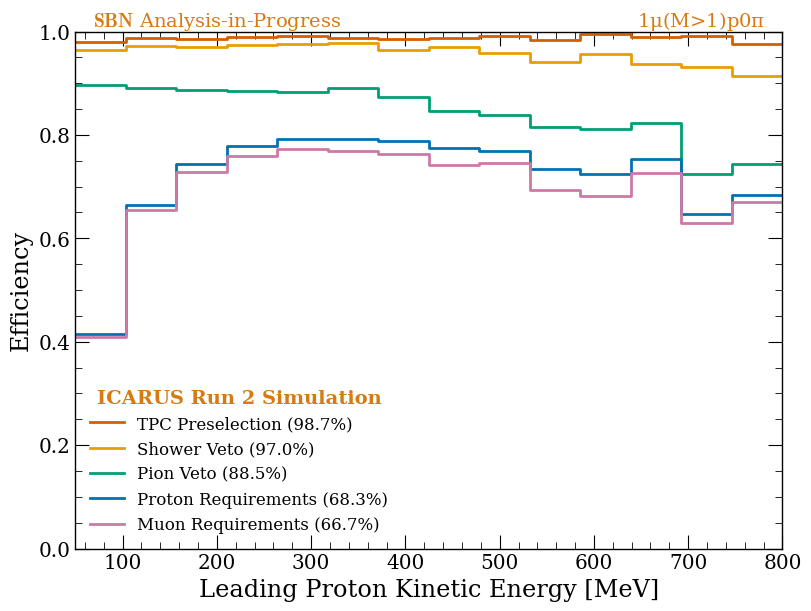

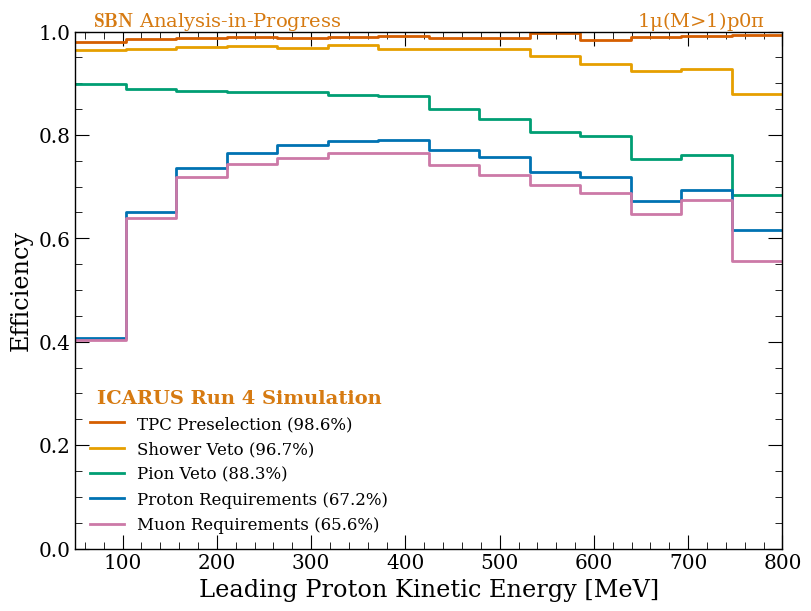

In [17]:
edges_efficiency = np.linspace(50, 800, 15)

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal,
        apply_proton_multiplicity,
        edges_efficiency,
        var_key='true_leading_proton_ke',
        xlabel='Leading Proton Kinetic Energy [MeV]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$Np0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_proton_ke.pdf'
    )

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal_ccqe,
        apply_proton_multiplicity_1p,
        edges_efficiency,
        var_key='true_leading_proton_ke',
        xlabel='Leading Proton Kinetic Energy [MeV]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$1p0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_proton_ke_singlep.pdf'
    )

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal_nproton,
        apply_proton_multiplicity_multip,
        edges_efficiency,
        var_key='true_leading_proton_ke',
        xlabel='Leading Proton Kinetic Energy [MeV]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$(M>1)p0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_proton_ke_multip.pdf'
    )

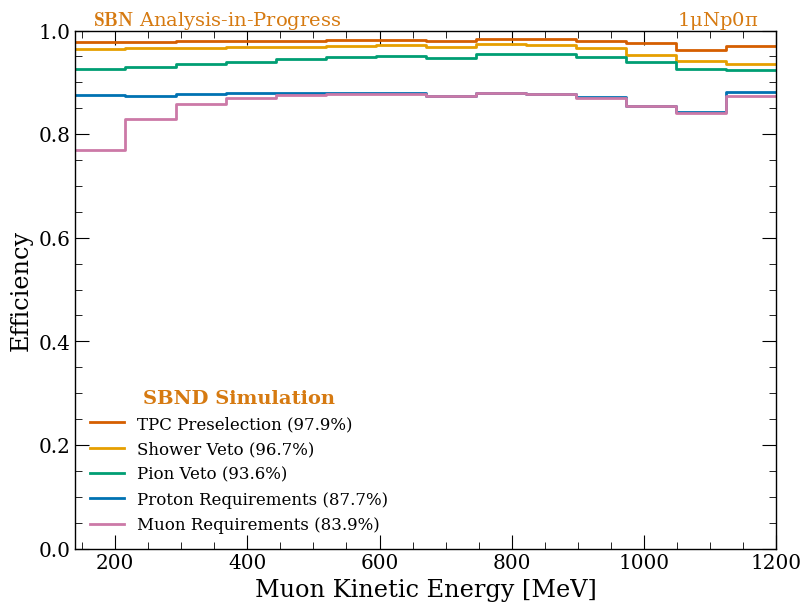

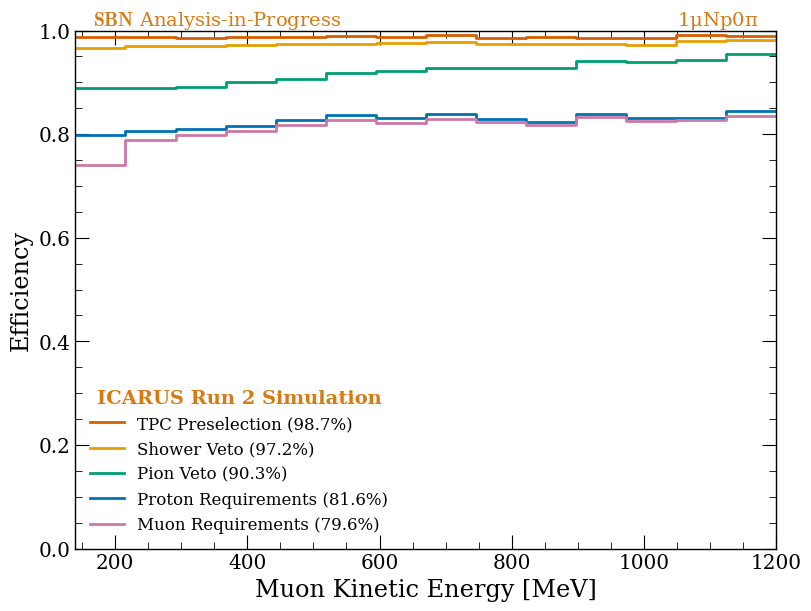

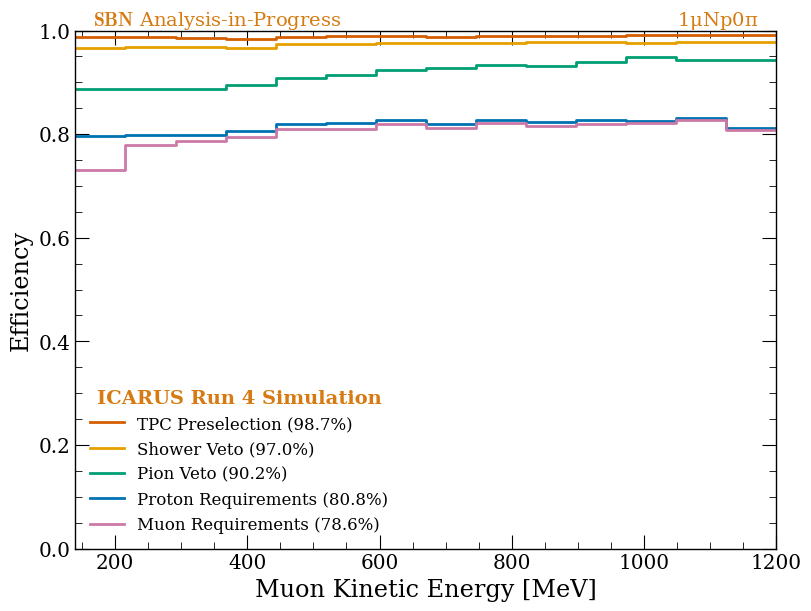

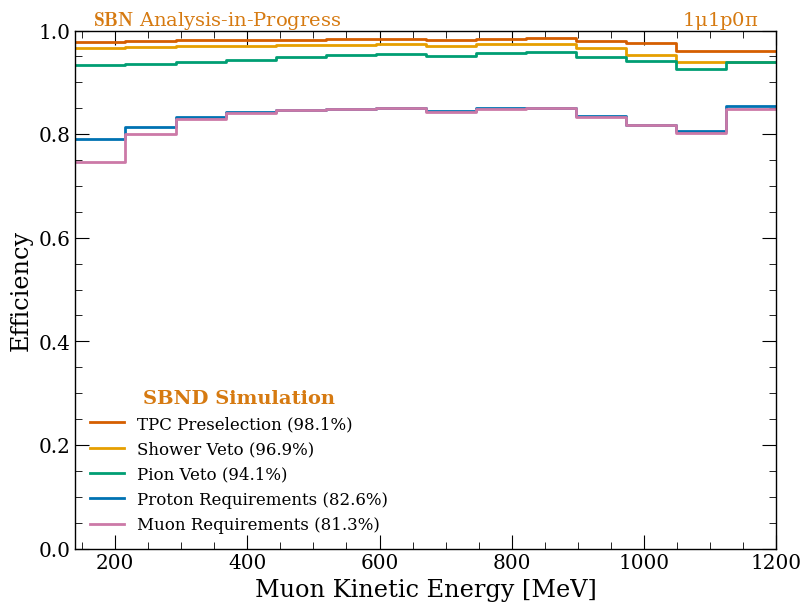

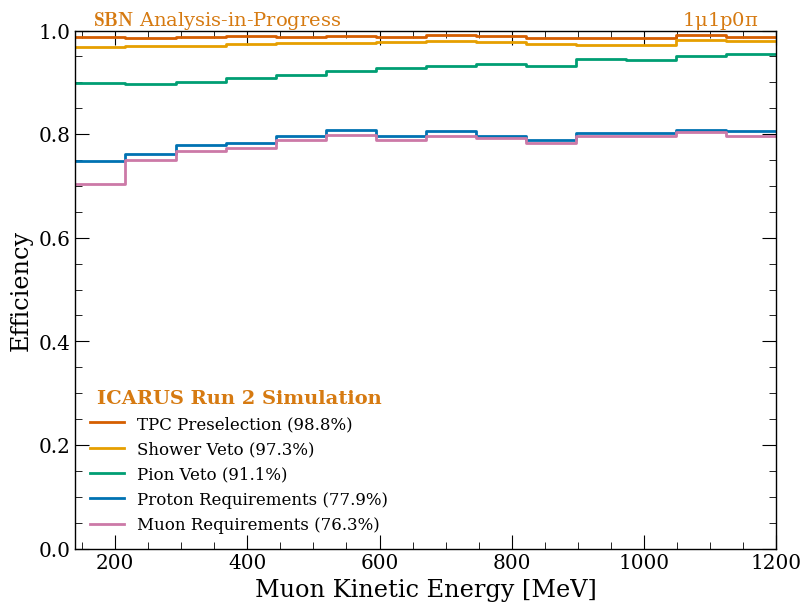

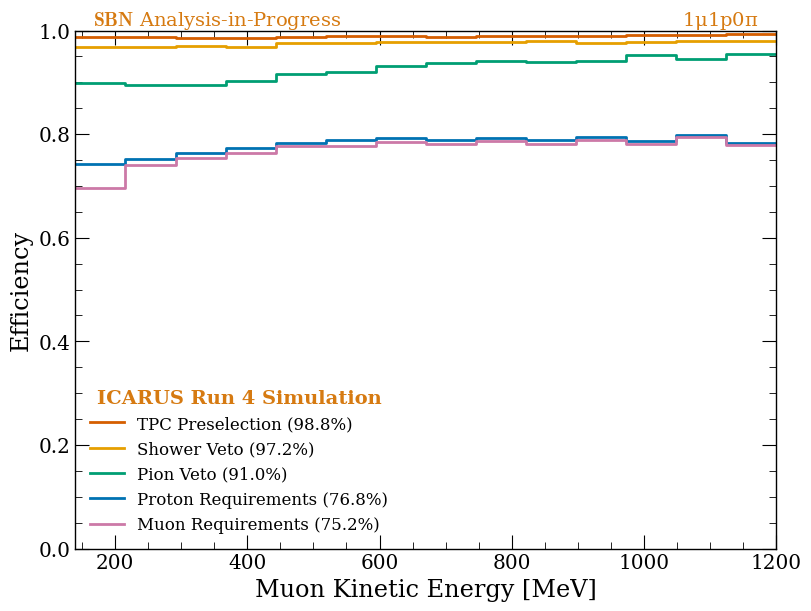

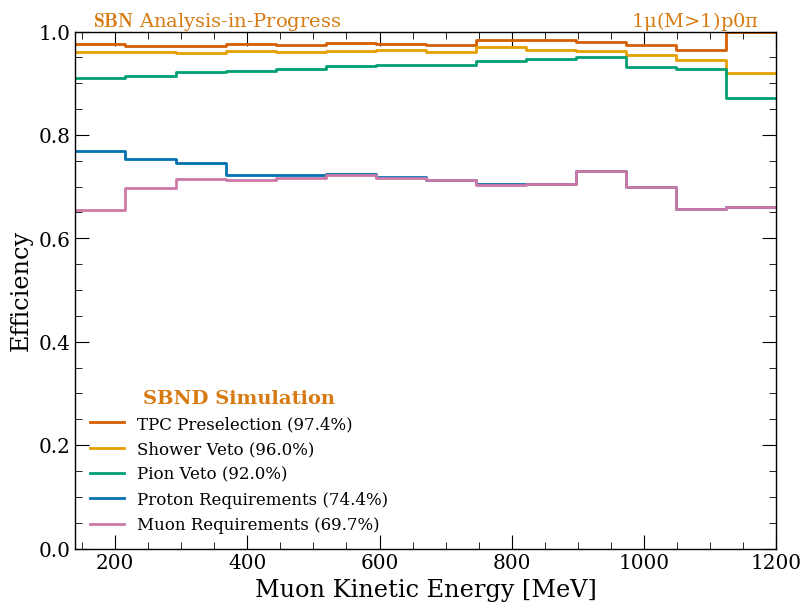

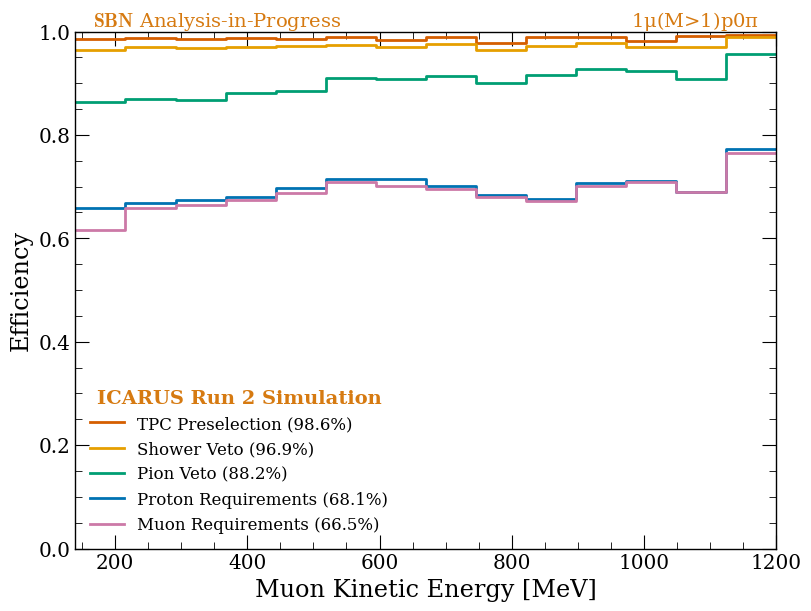

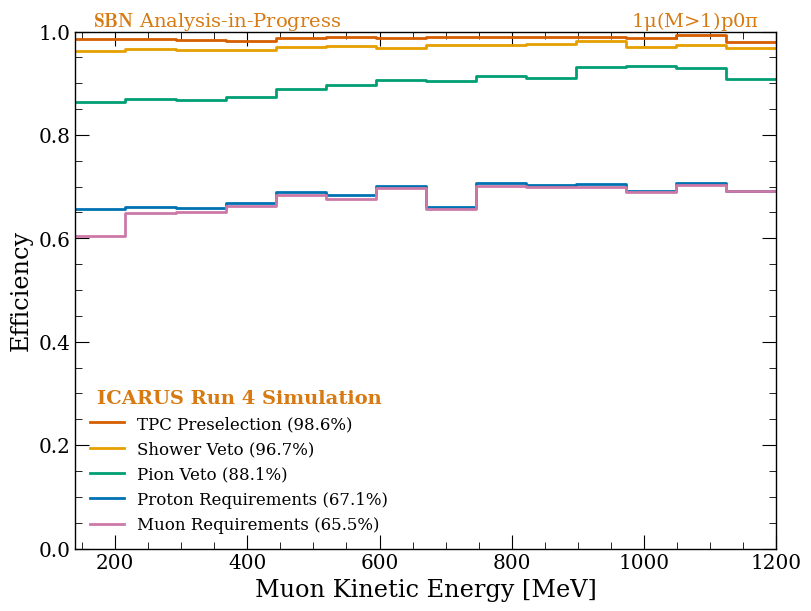

In [18]:
edges_efficiency = np.linspace(140, 1200, 15)

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal,
        apply_proton_multiplicity,
        edges_efficiency,
        var_key='true_leading_muon_ke',
        xlabel='Muon Kinetic Energy [MeV]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$Np0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_muon_ke.pdf'
    )

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal_ccqe,
        apply_proton_multiplicity_1p,
        edges_efficiency,
        var_key='true_leading_muon_ke',
        xlabel='Muon Kinetic Energy [MeV]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$1p0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_muon_ke_singlep.pdf'
    )

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal_nproton,
        apply_proton_multiplicity_multip,
        edges_efficiency,
        var_key='true_leading_muon_ke',
        xlabel='Muon Kinetic Energy [MeV]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$(M>1)p0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_muon_ke_multip.pdf'
    )